# 1 引言
**研究目的**：
本文参照广发证券《基于日内高频数据的短周期选股因子研究-高频数据因子研究系列一》，对该研报中构建的因子进行编程实现与结果复现，并开展相应分析。其中依托个股日内高频数据搭建选股因子、采用低频调仓的研究思路，具备较高的参考价值。

**研究内容**：
基于个股日内高频数据，构建已实现波动（Realized Volatility）$RVol$、已实现偏度（Realized Skewness）$RSkew$、已实现峰度（Realized Kurtosis）$RKurt$三类因子指标，检验上述三个因子在回测周期内对个股收益率的区分能力。

**研究结论**：
三类因子中，$RSkew$因子有效性最优，分组收益区分度显著且表现稳定，同时具备最高的收益水平。

# 2 因子构建
因子构建方法引自相关研报，具体指标构建流程如下：

1. 针对各只个股在交易日$t$，先计算其在指定分钟频率下第$i$期收益率$r_{t,i}$，计算公式为$\boldsymbol{r_{t,i}=p_{t,i}-p_{t,i-1}}$，式中$p_{t,i}$为个股在交易日$t$第$i$期指定分钟频率下的对数价格，$p_{t,i-1}$为对应交易日$t$第$i-1$期指定分钟频率下的对数价格。

2. 基于各只个股的$r_{t,i}$，分别计算其在交易日$t$的已实现方差（Realized Variance）$RDVar_t$、已实现偏度（Realized Skewness）$RDSkew_t$及已实现峰度（Realized Kurtosis）$RDKurt_t$，计算公式如下：
$$RDVar_t = \sum\limits_{i=1}^{n}r_{t,i}^2$$
$$RDSkew_t = \frac{\sqrt N\sum\limits_{i=1}^{n}r_{t,i}^3}{RDVar_t^{3/2}}$$
$$RDKurt_t = \frac{N \sum\limits_{i=1}^{n}r_{t,i}^4}{RDVar_t^2}$$
式中$N$为个股在交易日$t$对应指定频率的分钟级数据数量，例如1分钟行情下$N=60\times4=240$，5分钟行情下$N=240/5=48$。

3. 对各只个股在交易日$t$，计算累计已实现波动（Realized Volatility）$RVol_t$、已实现偏度（Realized Skewness）$RSkew_t$、已实现峰度（Realized Kurtosis）$RKurt_t$，计算公式如下：
$$RVol_t = \left(\frac{242}{n} {\sum\limits_{i=0}^{n}}RDVar_{t-i}\right)^{1/2}$$
$$RSkew_t = \frac{1}{n}{\sum\limits_{i=0}^{n}}RDSkew_{t-i}$$
$$RKurt_t = \frac{1}{n}{\sum\limits_{i=0}^{n}}RDKurt_{t-i}$$

4. 在每期调仓日的截面层面，依据上述公式测算每只个股的$RVol_t$、$RSkew_t$、$RKurt_t$指标，结合各高频因子在历史分档组合中的表现，筛选具备相对有效性的因子指标。

# 3 构造因子数据
因子值的计算耗时相对较长，整体运行时长约1小时。若直接下载已预处理完成的数据文件（factor_dict_datas.pkl）并上传至研究环境，可跳过本环节，直接从因子特征展示部分开始运行代码。

下文为因子值的具体计算过程：

In [9]:
# ==========================
# 基础依赖库导入模块
# 功能：加载项目所需全部工具包与全局参数定义
# ==========================
import pandas as pd
import numpy as np
from jqdata import *
import math
from pandas import *
from datetime import date, timedelta

# 全局回测与统计参数配置
LOOKBACK_PERIOD = 48
GROUP_QUANTILE = 5

In [2]:
# ==========================
# 高频波动率因子计算模块
# 基于5分钟高频数据计算已实现波动率、偏度、峰度因子
# 支持缓存机制加速计算、自动过滤异常标的与次新股
# ==========================

def compute_single_day_factor(cache_data: dict = None, stock_list: list = None, target_date: any = None):
    """
    计算单个交易日的高频因子值
    包含：已实现波动率、偏度、峰度
    自动过滤停牌股票，使用缓存提升计算效率
    """
    if cache_data is None:
        cache_data = {}
    
    # 获取过去N日交易日序列，用于计算累计波动率指标
    selected_trade_days = get_trade_days(
        start_date=None,
        end_date=target_date,
        count=GROUP_QUANTILE
    )

    stock_code_list = []
    factor_value_list = []

    for stock_code in stock_list:
        # 获取日频价格与停牌状态
        daily_price = get_price(
            stock_code,
            start_date=None,
            end_date=target_date,
            frequency='daily',
            fields=['paused', 'close'],
            skip_paused=False,
            fq='pre',
            count=GROUP_QUANTILE
        )

        # 提取当日收盘价
        current_close = daily_price.iloc[-1]['close']

        # 过滤存在停牌的数据，避免计算异常
        cleaned_price = daily_price.T.replace(1.0, np.nan).dropna()
        if len(cleaned_price.index.values.tolist()) == 0:
            continue

        # 累计统计量初始化
        total_realized_var = 0.0
        total_realized_skew = 0.0
        total_realized_kurt = 0.0

        # 遍历计算每日高频数据
        for single_day in selected_trade_days:
            # 缓存读取逻辑，避免重复请求
            if single_day in cache_data.keys() and stock_code in cache_data[single_day].keys():
                minute_bars = cache_data[single_day][stock_code]
            else:
                # 获取5分钟高频K线
                minute_bars = get_bars(
                    stock_code,
                    HIGH_FREQ_BAR_COUNT,
                    unit='5m',
                    fields=['date', 'open', 'high', 'low', 'close'],
                    include_now=False,
                    end_dt=single_day + timedelta(days=1),
                    fq_ref_date=None
                )

                if single_day not in cache_data.keys():
                    cache_data[single_day] = {}
                cache_data[single_day][stock_code] = minute_bars

            sum_rt_pow2 = 0.0
            sum_rt_pow3 = 0.0
            sum_rt_pow4 = 0.0

            # 逐K线计算对数收益率
            for bar_idx in range(1, HIGH_FREQ_BAR_COUNT):
                log_p_current = math.log(minute_bars[bar_idx]['close'])
                log_p_last = math.log(minute_bars[bar_idx - 1]['close'])
                log_return = log_p_current - log_p_last

                sum_rt_pow2 += math.pow(log_return, 2)
                sum_rt_pow3 += math.pow(log_return, 3)
                sum_rt_pow4 += math.pow(log_return, 4)

            # 当日已实现方差
            realized_var = sum_rt_pow2

            # 当日已实现偏度
            if sum_rt_pow3 == 0:
                realized_skew = 0.0
            else:
                realized_skew = math.sqrt(HIGH_FREQ_BAR_COUNT) * sum_rt_pow3 / (math.pow(realized_var, 3 / 2))

            # 当日已实现峰度
            if sum_rt_pow4 == 0:
                realized_kurt = 0.0
            else:
                realized_kurt = HIGH_FREQ_BAR_COUNT * sum_rt_pow4 / (math.pow(realized_var, 2))

            total_realized_var += realized_var
            total_realized_skew += realized_skew
            total_realized_kurt += realized_kurt

        # 计算最终因子
        realized_volatility = math.sqrt((242.0 / GROUP_QUANTILE) * total_realized_var)
        realized_skewness = (1.0 / GROUP_QUANTILE) * total_realized_skew
        realized_kurtosis = (1.0 / GROUP_QUANTILE) * total_realized_kurt

        # 保存结果
        stock_code_list.append(stock_code)
        factor_value_list.append([current_close, realized_volatility, realized_skewness, realized_kurtosis])

    # 构建因子数据表
    factor_result = pd.DataFrame(
        data=factor_value_list,
        index=stock_code_list,
        columns=['close', 'r_vol', 'r_skew', 'r_kurt']
    )
    return factor_result


def filter_unqualified_stocks(stock_pool: list, query_date: any):
    """
    股票池过滤：
    1. 剔除上市不满一年的新股
    2. 剔除ST、*ST股票
    """
    qualified_stocks = []
    for stock in stock_pool:
        ipo_date = get_security_info(stock).start_date
        if ipo_date < (query_date - timedelta(days=365)):
            qualified_stocks.append(stock)

    # 剔除ST标的
    st_status = get_extras('is_st', qualified_stocks, count=1, end_date=query_date)
    final_stock_list = [s for s in qualified_stocks if not st_status[s][0]]
    return final_stock_list


# ==========================
# 全样本因子计算主程序
# 样本区间：2013-2019，中证500成分股
# 每5个交易日计算一次因子值
# ==========================

# 全局参数配置
HIGH_FREQ_BAR_COUNT = 48
GROUP_QUANTILE = 5

# 回测时间区间
sample_start_date = date(2013, 1, 1)
sample_end_date = date(2019, 3, 27)
sample_trade_days = get_trade_days(
    start_date=sample_start_date,
    end_date=sample_end_date,
    count=None
)

# 全局缓存与因子存储字典
factor_cache = {}
factor_result_dataset = {}

# 逐期计算因子
for day_index in range(len(sample_trade_days)):
    # 每5天执行一次计算
    if day_index % GROUP_QUANTILE != 0:
        continue

    current_trade_day = sample_trade_days[day_index]
    print(current_trade_day)

    # 使用中证500作为股票池
    target_stock_pool = get_index_stocks('000905.XSHG', current_trade_day)

    # 过滤新股与ST
    filtered_stock_pool = filter_unqualified_stocks(target_stock_pool, current_trade_day)

    # 计算当期因子
    daily_factor = compute_single_day_factor(
        cache_data=factor_cache,
        stock_list=filtered_stock_pool,
        target_date=current_trade_day
    )
    factor_result_dataset[current_trade_day] = daily_factor

    # 限制缓存大小，避免内存溢出
    if len(factor_cache) > 5:
        keys_to_remove = []
        for cache_key in factor_cache.keys():
            if cache_key not in sample_trade_days[day_index - 5: day_index]:
                keys_to_remove.append(cache_key)
        for remove_key in keys_to_remove:
            del factor_cache[remove_key]

In [9]:
# ==========================
# 因子结果持久化存储模块
# 功能：将全周期计算完成的因子数据序列化保存至本地文件
# 用于后续策略回测与分析，避免重复计算
# ==========================
import pickle

# 以二进制写入模式打开文件，执行因子数据序列化存储
storage_file = open('factor_dict_datas.pkl', 'wb')
pickle.dump(factor_result_dataset, storage_file, protocol=0)
storage_file.close()

# 4 因子特征展示
基于前文代码运算，已得到中证500成分股在2013-2019年期间的因子数据。

本节将分别从因子频率分布、因子百分位走势两个维度对因子特征进行展示分析。
## 1 频率分布

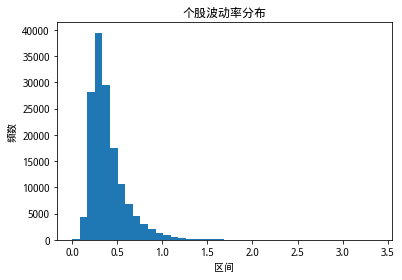

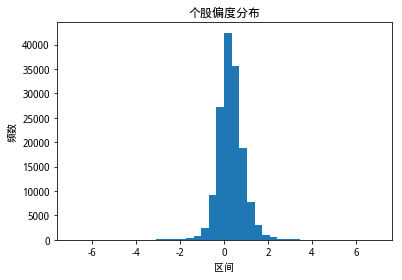

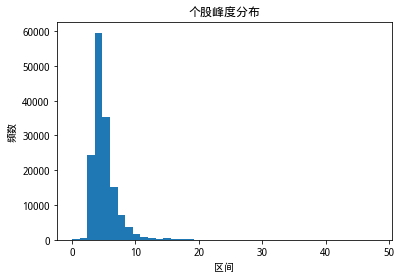

In [2]:
```python
# ==========================
# 因子数据可视化分析模块
# 功能：从本地加载已存储的因子数据，统计全样本个股波动率、偏度、峰度分布
# 输出标准化直方图，适配中文显示与负号展示
# ==========================
import pickle
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdate

# 加载本地持久化的因子数据集
pkl_file = open('factor_dict_datas.pkl', 'rb')
factor_result_dataset = pickle.load(pkl_file)
pkl_file.close()

# 全局绘图配置：中文与负号正常渲染
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 初始化全市场因子统计列表
volatility_collection = []
skewness_collection = []
kurtosis_collection = []

# 遍历所有交易日，收集全样本因子数值
for trade_date in factor_result_dataset:
    current_factor_df = factor_result_dataset[trade_date]
    total_stocks = len(current_factor_df)
    
    for idx in range(total_stocks):
        single_factor = current_factor_df.iloc[idx]
        volatility_collection.append(single_factor['r_vol'])
        skewness_collection.append(single_factor['r_skew'])
        kurtosis_collection.append(single_factor['r_kurt'])

# 统一绘图样式配置
hist_color = "#1F77B4"
bin_count = 40

# 绘制个股波动率分布直方图
plt.hist(volatility_collection, bins=bin_count, density=False, facecolor=hist_color, edgecolor=None, alpha=1)
plt.xlabel("数值区间")
plt.ylabel("样本频数")
plt.title("个股波动率分布")
plt.show()

# 绘制个股偏度分布直方图
plt.hist(skewness_collection, bins=bin_count, density=False, facecolor=hist_color, edgecolor=None, alpha=1)
plt.xlabel("数值区间")
plt.ylabel("样本频数")
plt.title("个股偏度分布")
plt.show()

# 绘制个股峰度分布直方图
plt.hist(kurtosis_collection, bins=bin_count, density=False, facecolor=hist_color, edgecolor=None, alpha=1)
plt.xlabel("数值区间")
plt.ylabel("样本频数")
plt.title("个股峰度分布")
plt.show()
```

从上述三张因子分布图可以观测到，全 A 股市场个股的波动率分布整体呈现右偏特征；个股偏度的整体水平围绕零值附近波动，分布具备显著的厚尾特征；个股峰度分布形态与波动率分布相近，整体同样呈右偏分布，且样本内个股的峰度数值多数大于 3，表现出厚尾特性。

## 2 百分位走势

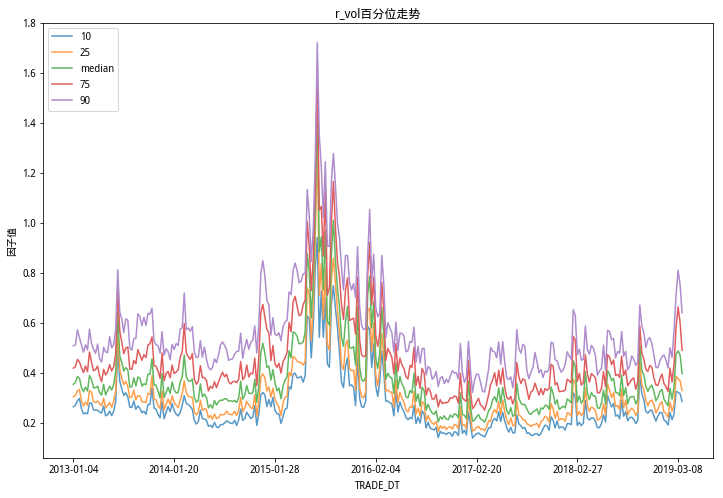

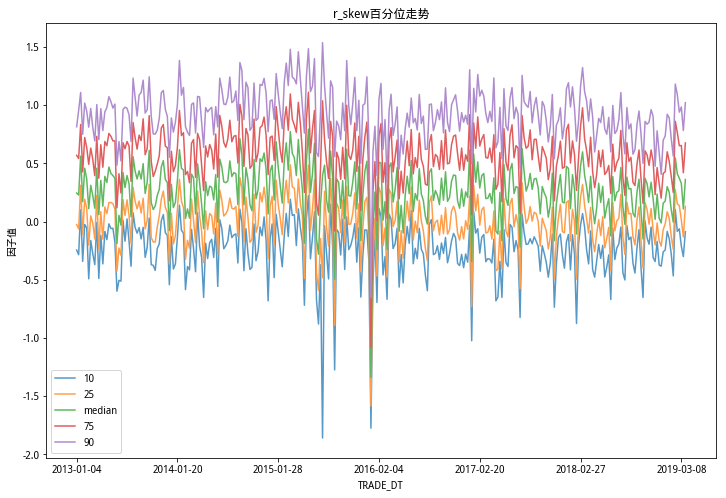

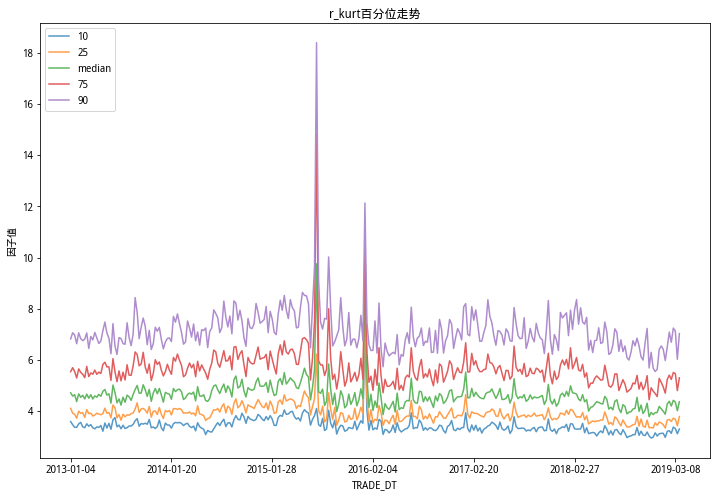

In [4]:
# ==========================
# 因子分位数时序趋势可视化模块
# 功能：绘制因子10/25/50/75/90分位数随时间的变化曲线
# 支持波动率、偏度、峰度三类指标，自动适配时间轴与配色方案
# ==========================
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import numpy as np

def visualize_factor_percentile_trend(factor_dataset, factor_column, legend_position):
    """
    绘制指定因子的分位数时序走势
    factor_dataset: 按日期存储的因子数据表字典
    factor_column: 因子名称 r_vol / r_skew / r_kurt
    legend_position: 图例位置
    """
    # 分位数曲线配色定义
    color_palette = ['#5698c6', '#ff9e4a', '#60b760', '#e05c5d', '#ae8ccd']
    quantile_labels = ['10%', '25%', 'median', '75%', '90%']
    
    # 存储各分位数时序数据
    quantile_series = [[], [], [], [], []]
    quantile_levels = [0.10, 0.25, 0.50, 0.75, 0.90]

    # 逐期提取并计算因子分位数
    for trade_date in factor_dataset:
        daily_factor_df = factor_dataset[trade_date]
        daily_factor_list = []
        
        # 提取当日全市场因子值
        for idx in range(len(daily_factor_df)):
            stock_factor = daily_factor_df.iloc[idx]
            daily_factor_list.append(stock_factor[factor_column])
        
        # 排序并计算分位数
        sorted_factor_array = np.array(daily_factor_list)
        sorted_factor_array.sort()
        total_sample_count = len(sorted_factor_array)

        for q_idx in range(len(quantile_levels)):
            position = int(quantile_levels[q_idx] * total_sample_count)
            quantile_value = sorted_factor_array[position]
            quantile_series[q_idx].append(quantile_value)

    # 初始化画布
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(factor_column + " 因子分位数时序走势")
    ax.xaxis.set_major_formatter(mdate.DateFormatter("%Y%m%d"))
    ax.xaxis.set_major_locator(mdate.DayLocator())

    # 绘制五条分位数曲线
    for line_idx in range(len(quantile_series)):
        y_data = quantile_series[line_idx]
        color = color_palette[line_idx]
        label = quantile_labels[line_idx]
        ax.plot(y_data, color=color, label=label)

    # 构建稀疏X轴刻度
    total_days = len(factor_dataset)
    tick_positions = np.arange(0, total_days, 50)
    date_keys = list(factor_dataset.keys())
    tick_labels = [date_keys[i] for i in tick_positions]

    # 设置X轴显示
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.xlabel("TRADE_DT")
    plt.ylabel("因子值")
    ax.legend(loc=legend_position, shadow=False)
    plt.show()

# ==========================
# 执行三类因子的分位数趋势可视化
# ==========================
visualize_factor_percentile_trend(factor_result_dataset, 'r_vol', 'upper left')
visualize_factor_percentile_trend(factor_result_dataset, 'r_skew', 'lower left')
visualize_factor_percentile_trend(factor_result_dataset, 'r_kurt', 'upper left')

从上述三张图表可以观察到，个股波动率在不同时间区间内波动幅度较大，在市场趋势性行情较为显著的阶段，个股波动率整体呈现上行态势；个股偏度水平整体表现相对平稳；在极端行情环境下，个股峰度水平会进一步提升，且各分位数之间的差异也更为突出。

# 5 实证分析
## 1 因子选股分档表现

In [5]:
# ==========================
# 因子分层回测与收益曲线可视化模块
# 功能：基于因子值将股票分为5档，计算各分组累计收益并绘图
# 自动对齐调仓周期，输出分组净值对比图
# ==========================
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import numpy as np
import pandas as pd

def split_stock_groups(factor_data: pd.DataFrame, group_num: int) -> list:
    """
    将股票按因子值均匀分为 N 组
    确保每组样本数量尽可能均衡
    """
    total_count = len(factor_data)
    group_size = total_count // group_num
    group_collection = []

    for idx in range(group_num - 1):
        start = idx * group_size
        end = (idx + 1) * group_size
        group_collection.append(factor_data.iloc[start:end])
    
    # 最后一组包含剩余样本
    group_collection.append(factor_data.iloc[(group_num - 1) * group_size:])
    return group_collection


def visualize_factor_group_return(return_table: pd.DataFrame, 
                                  factor_dataset: dict, 
                                  target_factor: str):
    """
    绘制单因子五组累计收益率曲线
    输入：收益率矩阵、因子字典、目标因子字段名
    输出：分组收益对比图
    """
    # 分组配色与标签
    color_scheme = ['#5698c6', '#ff9e4a', '#60b760', '#e05c5d', '#ae8ccd']
    group_names = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']

    # 初始化每组收益序列
    group_return_series = [[0.0], [0.0], [0.0], [0.0], [0.0]]
    previous_date = None

    # 遍历调仓日，逐期计算分组收益
    for current_date in factor_dataset:
        if previous_date is None:
            previous_date = current_date
            continue

        # 读取上期因子数据并排序
        last_period_factor = factor_dataset[previous_date].dropna()
        sorted_factor = last_period_factor.sort_values(by=target_factor)

        # 获取当期区间收益
        period_return = return_table.loc[previous_date]
        sorted_factor['period_return'] = period_return

        # 分为5组并计算平均收益
        stock_groups = split_stock_groups(sorted_factor, 5)
        for group_idx in range(len(stock_groups)):
            group = stock_groups[group_idx]
            group_mean_return = group['period_return'].mean()
            last_cum_return = group_return_series[group_idx][-1]
            group_return_series[group_idx].append(last_cum_return + group_mean_return)

        previous_date = current_date

    # 绘图设置
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"{target_factor} 分组累计收益率")

    # 绘制5条收益曲线
    for idx in range(len(group_return_series)):
        y_data = group_return_series[idx]
        ax.plot(y_data, color=color_scheme[idx], label=group_names[idx])

    # 设置X轴时间刻度
    total_days = len(factor_dataset)
    tick_positions = np.arange(0, total_days, 50)
    date_list = list(factor_dataset.keys())
    tick_labels = [date_list[i] for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.xlabel("TRADE_DT")
    plt.ylabel("累计收益率")
    ax.legend(loc='upper left', shadow=False)
    plt.show()


# ==========================
# 股票日度收益率矩阵构建
# 功能：基于收盘价计算期收益率，对齐调仓周期
# ==========================
return_index = []
return_data_matrix = []

for trade_day in factor_result_dataset:
    return_index.append(trade_day)
    daily_factor = factor_result_dataset[trade_day]
    close_series = daily_factor['close']
    return_data_matrix.append(close_series)

# 构建收益表并计算日收益率
return_table = pd.DataFrame(data=return_data_matrix, index=return_index)
return_table = return_table.pct_change()

# 上移对齐：当期因子 → 下期收益
return_table = return_table.shift(-1).fillna(0)

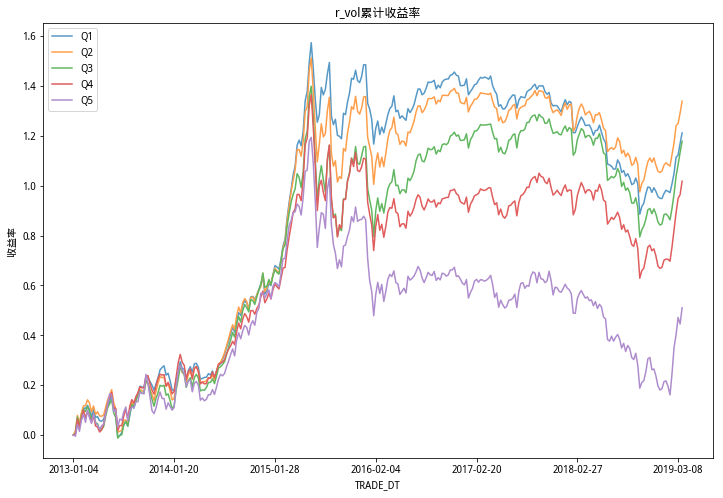

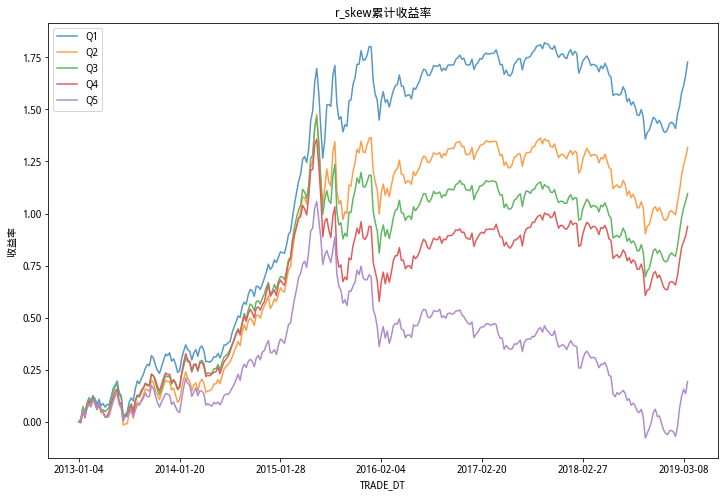

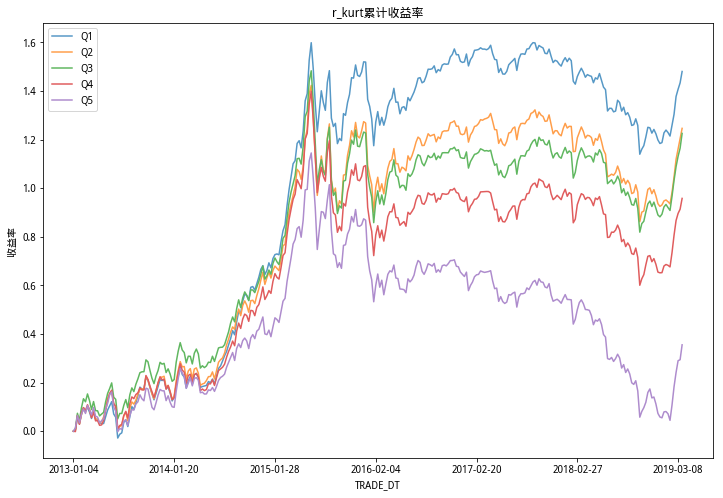

In [8]:
visualize_factor_group_return(return_table, factor_result_dataset, 'r_vol')
visualize_factor_group_return(return_table, factor_result_dataset, 'r_skew')
visualize_factor_group_return(return_table, factor_result_dataset, 'r_kurt')

从上述五组累计收益率分档图表可以看出，RSkew偏度因子的分档效果清晰，收益单调性表现突出；RVol因子的分档区分效果不显著；RKurt峰度因子的区分能力略弱于RSkew偏度因子，但优于RVol因子。

## 2 因子多空收益

In [9]:
# ==========================
# 因子多空策略收益分析模块
# 功能：计算因子多空组合（Q1 - Q5）累计收益并绘制收益曲线
# ==========================
import matplotlib.pyplot as plt
import numpy as np

def visualize_factor_long_short_return(return_data: pd.DataFrame, factor_dataset: dict, factor_column: str):
    """
    绘制指定因子的多空组合累计收益曲线
    多空收益 = Q1平均收益 - Q5平均收益
    """
    # 曲线样式设置
    curve_color = "red"
    curve_label = "多空累计收益"

    # 初始化多空收益序列，起始值为0
    long_short_return_series = [0.0]
    previous_trade_day = None

    # 遍历所有调仓日期
    for current_trade_day in factor_dataset:
        if previous_trade_day is None:
            previous_trade_day = current_trade_day
            continue

        # 获取上一期因子数据并排序
        previous_factor_data = factor_dataset[previous_trade_day].dropna()
        sorted_factor_data = previous_factor_data.sort_values(by=factor_column)

        # 获取对应区间收益
        period_return = return_data.loc[previous_trade_day]
        sorted_factor_data["ret"] = period_return

        # 将股票按因子值分为5组
        stock_groups = split_stock_groups(sorted_factor_data, 5)
        
        # 计算多空收益：Q1 - Q5
        q1_mean_return = stock_groups[0]["ret"].mean()
        q5_mean_return = stock_groups[4]["ret"].mean()
        current_long_short_return = q1_mean_return - q5_mean_return

        # 累计收益
        cumulative_return = long_short_return_series[-1] + current_long_short_return
        long_short_return_series.append(cumulative_return)

        previous_trade_day = current_trade_day

    # 绘图设置
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"{factor_column} 多空累计收益率")

    # 绘制多空收益曲线
    ax.plot(long_short_return_series, color=curve_color, label=curve_label)

    # 设置X轴时间刻度
    total_periods = len(factor_dataset)
    tick_positions = np.arange(0, total_periods, 50)
    date_keys = list(factor_dataset.keys())
    tick_labels = [date_keys[i] for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation="vertical")
    plt.xlabel("TRADE_DT")
    plt.ylabel("多空累计收益")
    ax.legend(loc="upper left", shadow=False)
    plt.show()

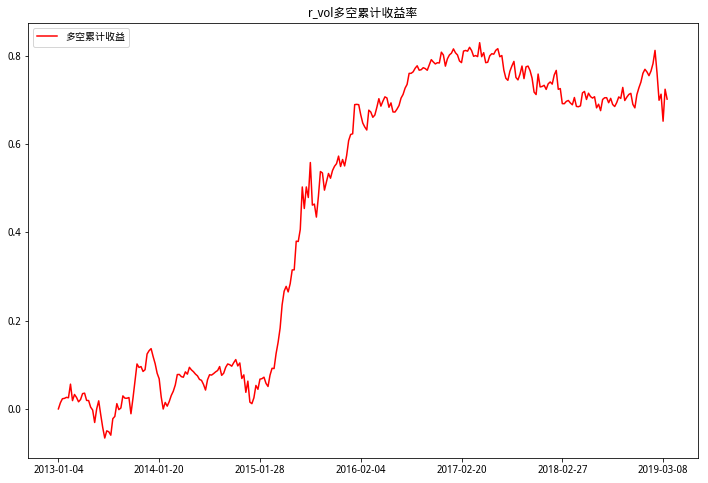

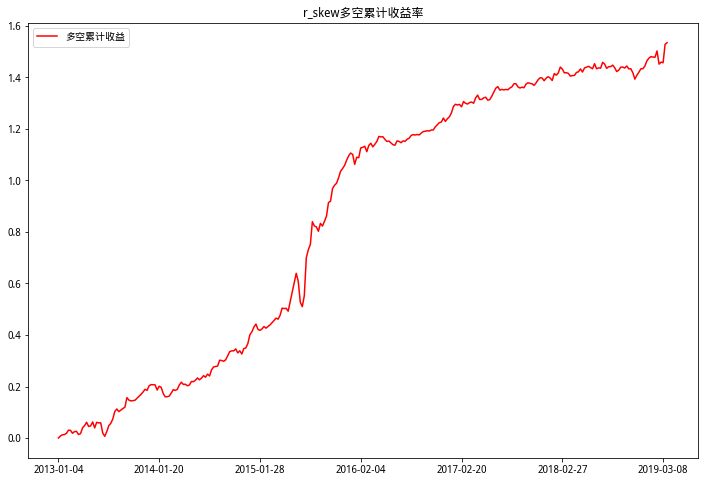

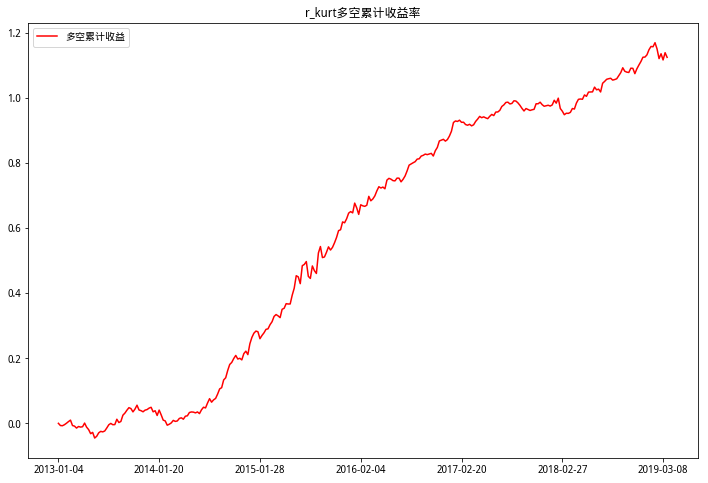

In [10]:
visualize_factor_long_short_return(return_table, factor_result_dataset, 'r_vol')
visualize_factor_long_short_return(return_table, factor_result_dataset, 'r_skew')
visualize_factor_long_short_return(return_table, factor_result_dataset, 'r_kurt')

从上述三张多空累计收益图表可以看出，RSkew偏度因子的多空收益水平最高且表现稳健，整体呈现持续上行走势，进一步验证了该因子的有效性。RKurt峰度因子在 2013-2014 年期间多空收益围绕 0 值波动，这一特征与该因子分档累计收益图中同期区分度不显著的结果相互吻合。

## 3 因子IC值计算

In [15]:
# ==========================
# 因子IC值计算与可视化模块
# 功能：计算因子与下期收益的皮尔逊相关系数（IC）
# 绘制IC时序曲线 + 12期滚动均值，输出负占比统计
# ==========================
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import numpy as np
import scipy.stats as st

def visualize_factor_ic_correlation(return_table: pd.DataFrame, 
                                    factor_dataset: dict, 
                                    factor_column: str):
    """
    计算并绘制因子IC时序曲线
    包含：当期IC值 + 12期滚动平均IC
    自动对齐股票池，处理长度不一致问题
    """
    # 配色与标签定义
    color_palette = ['#2B4C80', '#B00004']
    curve_labels = ['IC', 'IC均值(12期)']

    ic_time_series = []
    ic_rolling_ma = []

    # 遍历所有调仓日计算IC
    for trade_date in factor_dataset:
        # 获取当日因子序列
        current_factor_series = factor_dataset[trade_date][factor_column]
        # 获取当日下期收益序列
        current_return_series = return_table.loc[trade_date]

        # 对齐股票池（解决长度不一致问题）
        aligned_returns = []
        for stock_code in current_factor_series.index:
            aligned_returns.append(current_return_series[stock_code])

        # 计算皮尔逊相关系数（IC）
        ic_value = st.pearsonr(aligned_returns, current_factor_series)[0]
        ic_time_series.append(ic_value)

    # 统计IC为负的占比
    ic_array = np.array(ic_time_series)
    negative_ic_ratio = np.sum(ic_array < 0) / len(ic_array)
    print(f"{factor_column} 因子 IC 小于0的占比：{negative_ic_ratio:.4f}")

    # 计算12期滚动平均IC
    for idx in range(len(ic_time_series)):
        if idx < 12:
            ic_rolling_ma.append(np.nan)
        else:
            window_ic = ic_time_series[idx-12 : idx]
            ic_rolling_ma.append(np.mean(window_ic))

    # 绘图初始化
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"{factor_column} 因子 IC 时序")

    # 绘制两条曲线
    ax.plot(ic_time_series, color=color_palette[0], label=curve_labels[0])
    ax.plot(ic_rolling_ma, color=color_palette[1], label=curve_labels[1])

    # 设置X轴时间刻度
    total_days = len(factor_dataset)
    tick_positions = np.arange(0, total_days, 50)
    date_list = list(factor_dataset.keys())
    tick_labels = [date_list[i] for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation='vertical')
    plt.xlabel("TRADE_DT")
    plt.ylabel("IC 值")
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    ax.legend(loc='lower center', shadow=False)
    plt.show()

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in less


r_vol ic 小于0的个数占比：0.5973597359735974


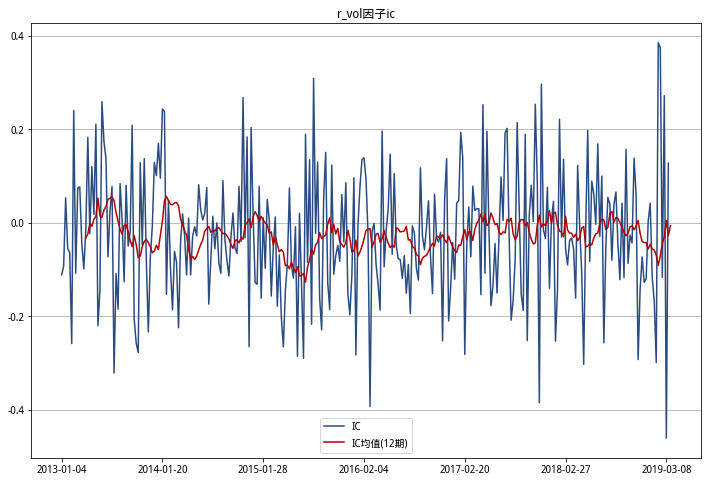

r_skew ic 小于0的个数占比：0.6600660066006601


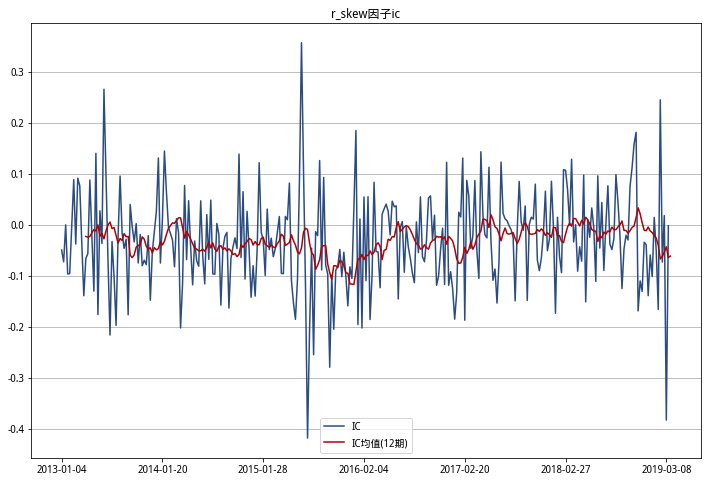

r_kurt ic 小于0的个数占比：0.66996699669967


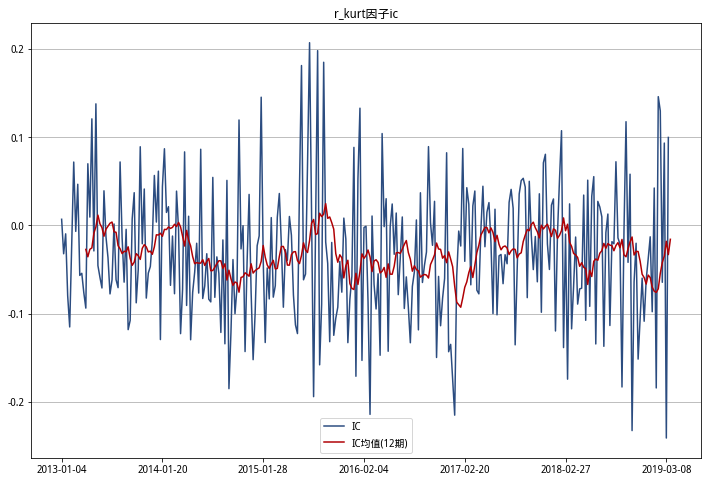

In [16]:
visualize_factor_ic_correlation(return_table, factor_result_dataset, 'r_vol')
visualize_factor_ic_correlation(return_table, factor_result_dataset, 'r_skew')
visualize_factor_ic_correlation(return_table, factor_result_dataset, 'r_kurt')

从上述三张 IC 图表可以观测到，RSkew偏度因子的平均 IC 数值整体小于 0，且 IC 为负值的占比超过 60%，因子具备良好的预测效果。
RSkew偏度因子在中证 500 指数样本内、2013-2019 年期间 IC 小于 0 的样本占比为 66%，该结果与研报中针对中证 500 指数的 IC 统计数据基本一致。受研究环境内存限制及因子构建运行时长的约束，本次研究未采用全市场数据开展测算，研报中全市场样本下 IC 小于 0 的占比未进行验证。

## 4因子换手率计算

In [13]:
# ==========================
# 因子分组换手率可视化模块
# 功能：计算因子Q1、Q5分组在调仓日的交叉换手率并绘制散点图
# 换手率 = 1 - 本期与上期组合重合数量 / 上期组合数量
# ==========================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def visualize_factor_turnover(factor_dataset: dict, factor_column: str):
    """
    绘制因子第1分位与第5分位的时序换手率散点图
    用于观察因子稳定性与换仓成本
    """
    # 存储第1组和第5组的换手率序列
    turnover_series = [[np.nan], [np.nan]]
    last_date = None

    # 遍历所有调仓日
    for current_date in factor_dataset:
        if last_date is None:
            last_date = current_date
            continue

        # --------------------------
        # 处理上一期数据
        # --------------------------
        last_factor_df = factor_dataset[last_date].dropna()
        last_factor_sorted = last_factor_df.sort_values(by=factor_column)
        last_groups = split_stock_groups(last_factor_sorted, 5)
        q1_last = last_groups[0]
        q5_last = last_groups[4]

        # --------------------------
        # 处理当期数据
        # --------------------------
        current_factor_df = factor_dataset[current_date].dropna()
        current_factor_sorted = current_factor_df.sort_values(by=factor_column)
        current_groups = split_stock_groups(current_factor_sorted, 5)
        q1_current = current_groups[0]
        q5_current = current_groups[4]

        # --------------------------
        # 计算 Q1 换手率
        # --------------------------
        q1_overlap = pd.merge(q1_last, q1_current, on=[factor_column])
        q1_turnover = 1 - len(q1_overlap) / len(q1_last)
        turnover_series[0].append(q1_turnover)

        # --------------------------
        # 计算 Q5 换手率
        # --------------------------
        q5_overlap = pd.merge(q5_last, q5_current, on=[factor_column])
        q5_turnover = 1 - len(q5_overlap) / len(q5_last)
        turnover_series[1].append(q5_turnover)

        last_date = current_date

    # --------------------------
    # 绘图部分
    # --------------------------
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"{factor_column} 因子分组换手率")

    # 绘制散点图
    x_indices = np.arange(len(factor_dataset))
    ax.scatter(x_indices, turnover_series[0], label="1分位换手率", s=15)
    ax.scatter(x_indices, turnover_series[1], label="5分位换手率", s=15)

    # 设置X轴时间刻度
    tick_positions = np.arange(0, len(factor_dataset), 50)
    date_list = list(factor_dataset.keys())
    tick_labels = [date_list[i] for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation="vertical")
    plt.grid(axis="y", alpha=0.3)
    plt.xlabel("TRADE_DT")
    plt.ylabel("换手率")
    ax.legend(loc="lower left", shadow=False)
    plt.show()

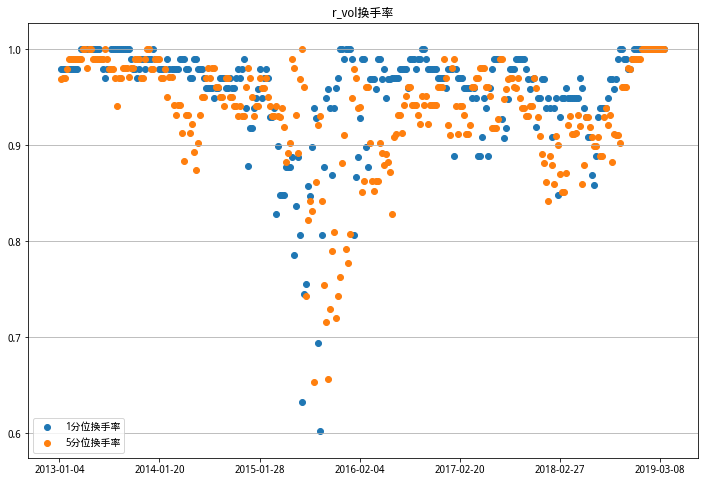

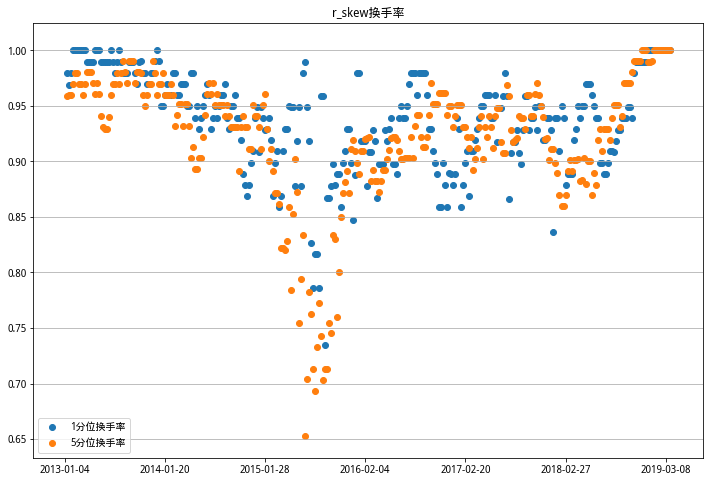

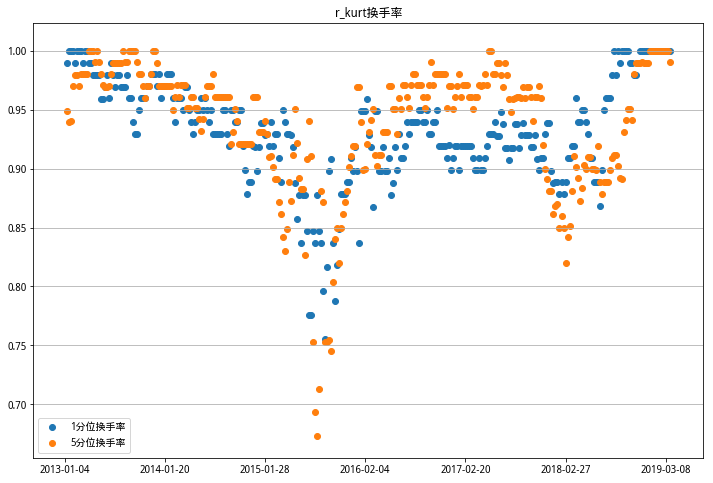

In [14]:
visualize_factor_turnover(factor_result_dataset, 'r_vol')
visualize_factor_turnover(factor_result_dataset, 'r_skew')
visualize_factor_turnover(factor_result_dataset, 'r_kurt')

# 6 结论
本研究从因子分布特征与因子百分位走势两个维度对因子特性进行展示，并从累计收益率、多空收益、因子IC及换手率等方面开展实证分析。

整体而言，本文采用中证500指数2013—2019年的数据进行选股测试，对研报中的相关内容基本完成复现，并得到如下结论：在三类因子中，偏度$RSkew$因子有效性最优，具备良好的分组区分度，表现稳定且收益水平最高。本次复现结果与原研报结论基本一致，验证了该研报结论的可靠性。